In [1]:
import os, json, time, random, warnings
import numpy as np
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF:', tf.__version__)
print('MediaPipe:', mp.__version__)
print('OpenCV:', cv2.__version__)


TF: 2.15.0
MediaPipe: 0.10.14
OpenCV: 4.11.0


In [6]:
#  Paths 
raw_dataset_path = r'C:\Users\rrree\ASLproject\datasets\asl_alphabet_train'
processed_path   = r'C:\Users\rrree\ASLproject\asl_processed'
landmarks_path   = r'C:\Users\rrree\ASLproject\landmarks.npz'
model_save_path  = r'C:\Users\rrree\ASLproject\AlphabetModel\landmarks_model.h5'
class_path   = r'C:\Users\rrree\ASLproject\class_indices.json'

#  Image settings 
image_size         = 128
hand_margin      = 0.20
detection_resize = 640

#  Classes 
Letters     = [chr(c) for c in range(ord('A'), ord('Z') + 1)]
num_classes = 26

#  Landmark settings 
num_landmarks  = 21          # MediaPipe gives 21 hand keypoints
coords_per_pt  = 3           # x, y, z per keypoint
feature_size   = num_landmarks * coords_per_pt   # 63 input features

#  Augmentation per image 
# We augment each image and extract landmarks from each version
num_augments   = 5           

#  Training 
batch_size  = 256           
epochs      = 100
LR          = 1e-3 #learning rate
val_split   = 0.20

image_extentions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

os.makedirs(processed_path, exist_ok=True)
os.makedirs(Path(model_save_path).parent, exist_ok=True)

print(f'  Classes      : {num_classes}')
print(f'  Feature size : {feature_size}  (21 keypoints × 3 coords)')
print(f'  Augments/img : {num_augments}')
print(f'  Epochs       : {epochs}')

  Classes      : 26
  Feature size : 63  (21 keypoints × 3 coords)
  Augments/img : 5
  Epochs       : 100


Found 26/26 letter folders
Total images : 78,000


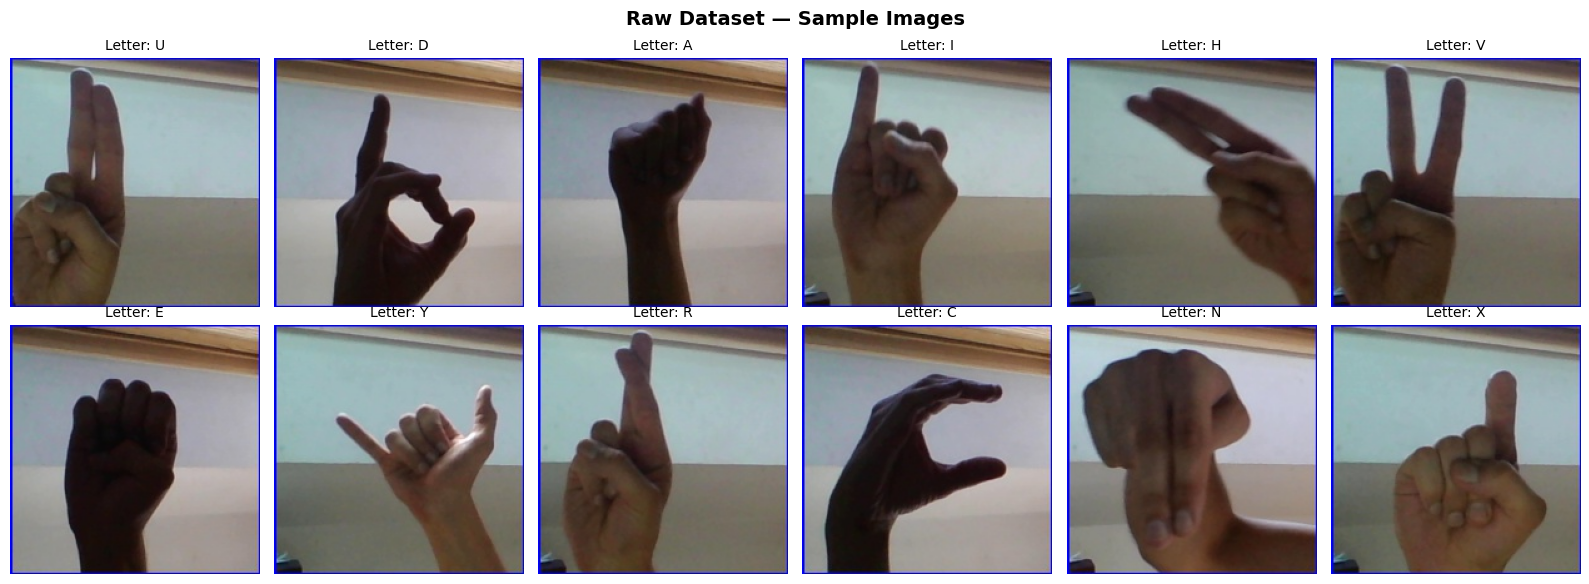

In [9]:
#  Verify the raw dataset exists and count images
raw_root = Path(raw_dataset_path)

if not raw_root.exists():
    raise FileNotFoundError(f'Dataset not found at: {raw_dataset_path}')

found = sorted([d.name for d in raw_root.iterdir()
                if d.is_dir() and d.name in Letters])
total = sum(len(list((raw_root / l).glob('*.*'))) for l in found)

print(f'Found {len(found)}/26 letter folders')
print(f'Total images : {total:,}')

#  Preview a sample of raw images 
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, letter in zip(axes.flatten(), random.sample(found, 12)):
    imgs = list((raw_root / letter).glob('*.jpg'))[:1]
    if imgs:
        ax.imshow(cv2.cvtColor(cv2.imread(str(imgs[0])), cv2.COLOR_BGR2RGB))
        ax.set_title(f'Letter: {letter}', fontsize=10)
    ax.axis('off')

plt.suptitle('Raw Dataset — Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
def crop_hand(img_bgr, margin=hand_margin,
              det_resize=detection_resize, out_size= image_size):

    h_orig, w_orig = img_bgr.shape[:2]

    # Down-scale before detection for speed
    scale = 1.0
    if max(h_orig, w_orig) > det_resize:
        scale = det_resize / max(h_orig, w_orig)
        small = cv2.resize(img_bgr, (int(w_orig * scale), int(h_orig * scale)))
    else:
        small = img_bgr

    mp_hands = mp.solutions.hands
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1,
                        min_detection_confidence=0.4) as hands:
        result = hands.process(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))

    if not result.multi_hand_landmarks:
        # If no hand is found, return the full image as fallback
        return cv2.resize(img_bgr, (out_size, out_size)), False

    # Convert normalised landmark coords back to original image pixels
    h_s, w_s = small.shape[:2]
    lms = result.multi_hand_landmarks[0].landmark
    xs  = [int(lm.x * w_s / scale) for lm in lms]
    ys  = [int(lm.y * h_s / scale) for lm in lms]

    # Build bounding box and add margin
    bw = max(xs) - min(xs)
    bh = max(ys) - min(ys)
    x1 = max(0,      min(xs) - int(bw * margin))
    y1 = max(0,      min(ys) - int(bh * margin))
    x2 = min(w_orig, max(xs) + int(bw * margin))
    y2 = min(h_orig, max(ys) + int(bh * margin))

    crop = img_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        crop = img_bgr

    return cv2.resize(crop, (out_size, out_size)), True

print('crop_hand() defined.')

crop_hand() defined.


In [11]:
# preprocessing 

raw_root  = Path(raw_dataset_path)
proc_root = Path(processed_path)

task_pairs = []
for letter in Letters:
    src_dir = raw_root  / letter
    dst_dir = proc_root / letter
    if not src_dir.exists():
        continue
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img_path in src_dir.iterdir():
        if img_path.suffix.lower() in image_extentions:
            task_pairs.append((str(img_path), str(dst_dir / img_path.name)))

already_done = sum(1 for _, d in task_pairs if Path(d).exists())
print(f'Total images : {len(task_pairs):,}')
print(f'Already done : {already_done:,}')
print(f'To process   : {len(task_pairs) - already_done:,}')

counters = {'ok': 0, 'fallback': 0, 'error': 0, 'skip': 0}
t0 = time.time()

for src_str, dst_str in tqdm(task_pairs, desc='Preprocessing', unit='img'):
    if Path(dst_str).exists():
        counters['skip'] += 1
        continue

    img = cv2.imread(src_str)
    if img is None:
        counters['error'] += 1
        continue

    cropped, detected = crop_hand(img)
    cv2.imwrite(dst_str, cropped)
    counters['ok' if detected else 'fallback'] += 1

elapsed = timedelta(seconds=int(time.time() - t0))
print(f'\nDone in {elapsed}')
print(f"   Hand detected  : {counters['ok']:,}")
print(f"   Fallback (full): {counters['fallback']:,}")
print(f"   Errors         : {counters['error']:,}")
print(f"   Skipped (done) : {counters['skip']:,}")

Total images : 78,000
Already done : 0
To process   : 78,000


Preprocessing:   0%|          | 0/78000 [00:00<?, ?img/s]


Done in 2:00:52
   Hand detected  : 61,455
   Fallback (full): 16,545
   Errors         : 0
   Skipped (done) : 0


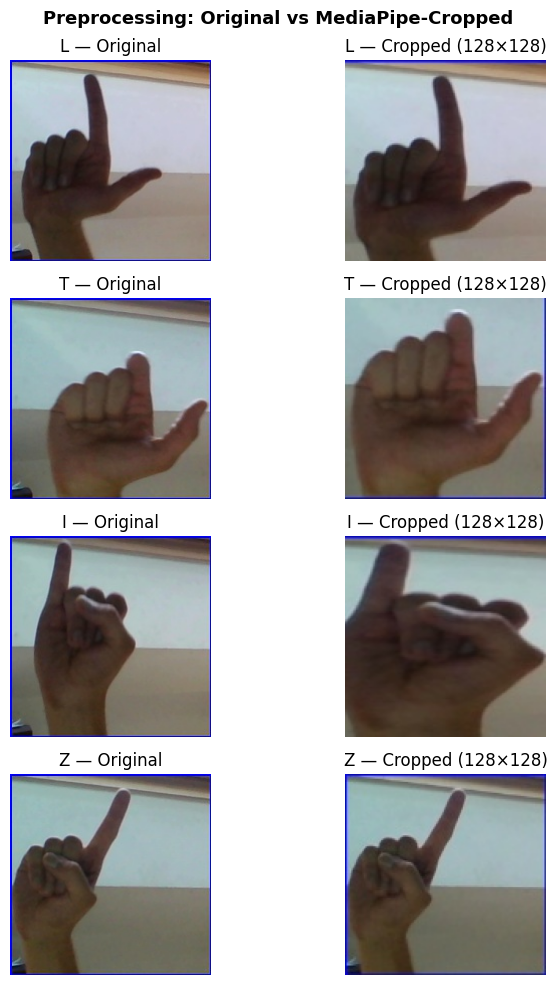

In [14]:
# Original vs Cropped 
sample_letters = random.sample(Letters, 4)
fig, axes = plt.subplots(4, 2, figsize=(8, 10))

for row, letter in enumerate(sample_letters):
    raw_imgs  = list((raw_root  / letter).glob('*.jpg'))[:1]
    proc_imgs = list((proc_root / letter).glob('*.jpg'))[:1]
    if raw_imgs:
        axes[row, 0].imshow(cv2.cvtColor(cv2.imread(str(raw_imgs[0])),  cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f'{letter} — Original')
    if proc_imgs:
        axes[row, 1].imshow(cv2.cvtColor(cv2.imread(str(proc_imgs[0])), cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f'{letter} — Cropped ({image_size}×{image_size})')
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Preprocessing: Original vs MediaPipe-Cropped', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
def augment_image(img_bgr):
#Apply random augmentation to a BGR image.

    h, w = img_bgr.shape[:2]

    #  Rotation 
    angle = random.uniform(-20, 20)
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    img = cv2.warpAffine(img_bgr, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    #  Brightness & contrast 
    alpha = random.uniform(0.4, 1.8)   # contrast
    beta  = random.randint(-40, 40)    # brightness
    img   = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    #  Zoom 
    zoom = random.uniform(0.85, 1.15)
    zh, zw = int(h * zoom), int(w * zoom)
    if zoom > 1.0:
        img = cv2.resize(img, (zw, zh))
        y1  = (zh - h) // 2
        x1  = (zw - w) // 2
        img = img[y1:y1+h, x1:x1+w]
    else:
        img = cv2.resize(img, (zw, zh))
        pad_y = (h - zh) // 2
        pad_x = (w - zw) // 2
        img = cv2.copyMakeBorder(img, pad_y, h-zh-pad_y,
                                      pad_x, w-zw-pad_x,
                                      cv2.BORDER_REFLECT)

    #  Random channel shift (skin tone / lighting color variation) 
    shift = np.random.randint(-40, 40, 3)
    img   = np.clip(img.astype(np.int32) + shift, 0, 255).astype(np.uint8)

    return img


def extract_landmarks(img_bgr, mp_hands_instance):
  
    rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result = mp_hands_instance.process(rgb)

    if not result.multi_hand_landmarks:
        return None

    landmarks = result.multi_hand_landmarks[0].landmark

    # Raw coordinates
    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])  # (21, 3)

    # Translate: subtract wrist (landmark 0)
    coords -= coords[0]

    # Scale: divide by max distance from wrist
    max_dist = np.max(np.linalg.norm(coords, axis=1)) + 1e-6
    coords  /= max_dist

    return coords.flatten()   # (63,)


print('Helper functions defined.')

Helper functions defined.


In [17]:
#  Extract landmarks from all images 
if Path(landmarks_path).exists():
    print(f'Landmarks already extracted at {landmarks_path}')
    print('Loading...')
    data      = np.load(landmarks_path)
    X         = data['X']
    y         = data['y']
    print(f'Loaded: X={X.shape}, y={y.shape}')

else:
    print('Extracting landmarks (augment first then extract)')

    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    proc_root = Path(processed_path)

    X_list, y_list = [], []
    failed = 0

    mp_hands = mp.solutions.hands.Hands(
        static_image_mode        = True,
        max_num_hands            = 1,
        min_detection_confidence = 0.4,
    )

    t0 = time.time()

    for label_idx, letter in enumerate(Letters):
        letter_dir = proc_root / letter
        if not letter_dir.exists():
            continue

        img_paths = [p for p in letter_dir.iterdir()
                     if p.suffix.lower() in image_extensions]

        for img_path in tqdm(img_paths, desc=f'{letter}', leave=False):
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                continue

            #  Augment first then extract landmarks 
            # Model learns to generalize across lighting/rotation/zoom
            versions = [img_bgr] + [augment_image(img_bgr) for _ in range(num_augments)]

            for version in versions:
                features = extract_landmarks(version, mp_hands)
                if features is not None:
                    X_list.append(features)
                    y_list.append(label_idx)
                else:
                    failed += 1

        print(f'  {letter} done — total samples so far: {len(X_list):,}')

    mp_hands.close()

    X = np.array(X_list, dtype=np.float32)   # (N, 63)
    y = np.array(y_list, dtype=np.int32)     # (N,)

    # Save so we never have to do this again
    np.savez_compressed(landmarks_path, X=X, y=y)

    elapsed = timedelta(seconds=int(time.time() - t0))
    print(f'\nDone in {elapsed}')
    print(f'Total samples extracted : {len(X):,}')
    print(f'Failed (no hand found)  : {failed:,}')
    print(f'Saved to: {landmarks_path}')

Extracting landmarks (augment first then extract)


A:   0%|          | 0/3000 [00:00<?, ?it/s]

  A done — total samples so far: 1,655


B:   0%|          | 0/3000 [00:00<?, ?it/s]

  B done — total samples so far: 2,934


...

  X done — total samples so far: 60,414


Y:   0%|          | 0/3000 [00:00<?, ?it/s]

  Y done — total samples so far: 67,625


Z:   0%|          | 0/3000 [00:00<?, ?it/s]

  Z done — total samples so far: 70,989

Done in 1:58:19
Total samples extracted : 70,989
Failed (no hand found)  : 397,011
Saved to: C:\Users\rrree\ASLproject\landmarks.npz


X shape : (70989, 63)   (samples × 63 features)
y shape : (70989,)
Classes : 26


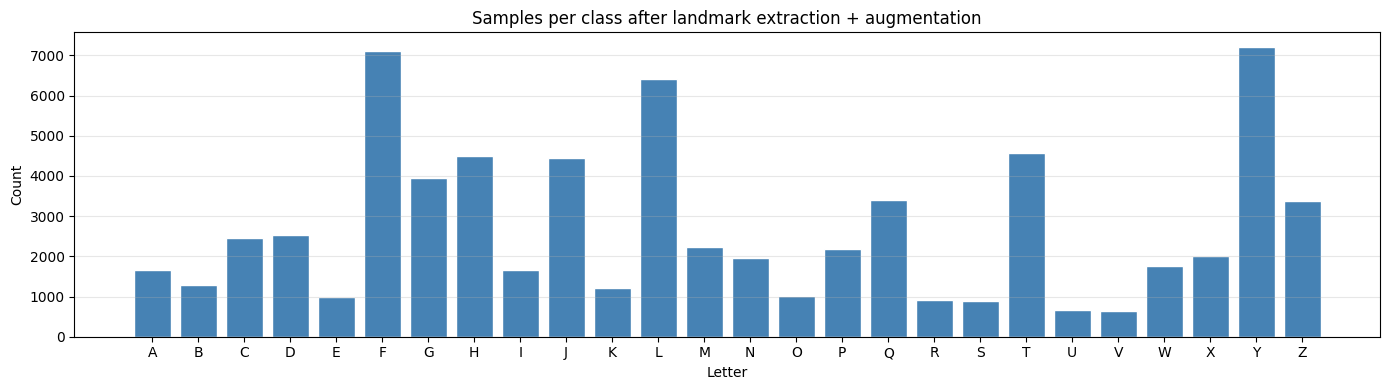

In [19]:
print(f'X shape : {X.shape}   (samples × 63 features)')
print(f'y shape : {y.shape}')
print(f'Classes : {num_classes}')

# Class distribution
unique, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar([Letters[i] for i in unique], counts, color='steelblue', edgecolor='white')
ax.set_title('Samples per class after landmark extraction + augmentation')
ax.set_xlabel('Letter')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# One-hot encode labels
y_onehot = tf.keras.utils.to_categorical(y, num_classes)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_onehot,
    test_size    = val_split,
    random_state = SEED,
    stratify     = y,        # equal class distribution in both splits
)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')

Train : (56791, 63)
Val   : (14198, 63)


In [22]:
def build_mlp(input_size, num_classes):
    inputs = keras.Input(shape=(input_size,), name='landmarks')

    # Layer 1
    x = layers.Dense(512, use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.40)(x)

    # Layer 2
    x = layers.Dense(256, use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.35)(x)

    # Layer 3
    x = layers.Dense(128, use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.30)(x)

    # Output
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='ASL_Landmarks_MLP')


model = build_mlp(feature_size, num_classes)
model.summary(line_length=60)

print(f'\nTotal parameters: {model.count_params():,}')


Model: "ASL_Landmarks_MLP"
____________________________________________________________
 Layer (type)              Output Shape            Param #  
 landmarks (InputLayer)    [(None, 63)]            0        
                                                            
 dense (Dense)             (None, 512)             32256    
                                                            
 batch_normalization (Bat  (None, 512)             2048     
 chNormalization)                                           
                                                            
 re_lu (ReLU)              (None, 512)             0        
                                                            
 dropout (Dropout)         (None, 512)             0        
                                                            
 dense_1 (Dense)           (None, 256)             131072   
                                                            
 batch_normalization_1 (B  (None, 256)             1024  

In [26]:
model.compile(
    optimizer = keras.optimizers.Adam(LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    ModelCheckpoint(
        filepath       = model_save_path,
        monitor        = 'val_accuracy',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1,
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 15,
        restore_best_weights = True,
        mode                 = 'max',
        verbose              = 1,
    ),
    ReduceLROnPlateau(
        monitor  = 'val_accuracy',
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6,
        mode     = 'max',
        verbose  = 1,
    ),
]

t0 = time.time()

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = epochs,
    batch_size      = batch_size,
    callbacks       = callbacks,
    verbose         = 1,
)

print(f'\nTotal training time: {timedelta(seconds=int(time.time()-t0))}')

Epoch 1/100


218/222 [============================>.] - ETA: 0s - loss: 1.3517 - accuracy: 0.6491
Epoch 1: val_accuracy improved from -inf to 0.54775, saving model to C:\Users\rrree\ASLproject\AlphabetModel\landmarks_model.h5
222/222 [==============================] - 3s 8ms/step - loss: 1.3446 - accuracy: 0.6507 - val_loss: 1.6670 - val_accuracy: 0.5478 - lr: 0.0010
Epoch 2/100
218/222 [============================>.] - ETA: 0s - loss: 0.9297 - accuracy: 0.7527
Epoch 2: val_accuracy improved from 0.54775 to 0.78131, saving model to C:\Users\rrree\ASLproject\AlphabetModel\landmarks_model.h5
222/222 [==============================] - 1s 6ms/step - loss: 0.9284 - accuracy: 0.7529 - val_loss: 0.8155 - val_accuracy: 0.7813 - lr: 0.0010
Epoch 3/100
220/222 [============================>.] - ETA: 0s - loss: 0.8377 - accuracy: 0.7761
Epoch 3: val_accuracy improved from 0.78131 to 0.81892, saving model to C:\Users\rrree\ASLproject\AlphabetModel\landmarks_model.h5
222/222 [====================

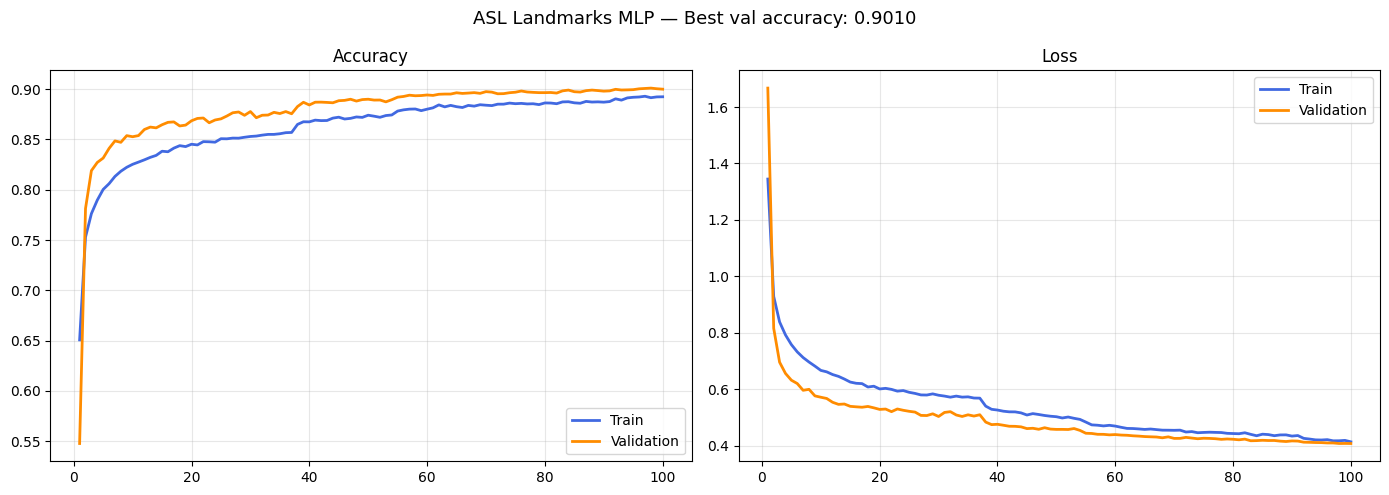

Best validation accuracy: 0.9010


In [27]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
ep       = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, acc,     label='Train',      color='royalblue', lw=2)
ax1.plot(ep, val_acc, label='Validation', color='darkorange', lw=2)
ax1.set_title('Accuracy');  ax1.legend();  ax1.grid(alpha=0.3)

ax2.plot(ep, loss,     label='Train',      color='royalblue', lw=2)
ax2.plot(ep, val_loss, label='Validation', color='darkorange', lw=2)
ax2.set_title('Loss');  ax2.legend();  ax2.grid(alpha=0.3)

best_val = max(val_acc)
plt.suptitle(f'ASL Landmarks MLP — Best val accuracy: {best_val:.4f}', fontsize=13)
plt.tight_layout()
plt.savefig('landmarks_training_curves.png', dpi=120)
plt.show()
print(f'Best validation accuracy: {best_val:.4f}')

In [29]:
class_to_index = {letter: idx for idx, letter in enumerate(Letters)}
index_to_class = {str(idx): letter for idx, letter in enumerate(Letters)}

with open(class_path, 'w') as f:
    json.dump({
        
        'class_to_index': class_to_index,
        'index_to_class': index_to_class
    }, f, indent=2)

print(f'Saved: {class_path}')
print(f'Mapping: {index_to_class}')

Saved: C:\Users\rrree\ASLproject\class_indices.json
Mapping: {'0': 'A', '1': 'B', '2': 'C', '3': 'D', '4': 'E', '5': 'F', '6': 'G', '7': 'H', '8': 'I', '9': 'J', '10': 'K', '11': 'L', '12': 'M', '13': 'N', '14': 'O', '15': 'P', '16': 'Q', '17': 'R', '18': 'S', '19': 'T', '20': 'U', '21': 'V', '22': 'W', '23': 'X', '24': 'Y', '25': 'Z'}
